In [1]:
import pandas as pd
import numpy as np 

In [15]:
import pandas as pd
from tabulate import tabulate

# Define the file path
file_path = r"C:\Users\user\OneDrive\Desktop\Data\sales_data_sample.csv"

# Read the CSV file with ISO-8859-1 encoding
df = pd.read_csv(file_path, encoding="ISO-8859-1")

# Display a random sample of 100 rows in a grid format
print(tabulate(df.sample(100), headers="keys", tablefmt="grid"))

+------+---------------+-------------------+-------------+-------------------+----------+-----------------+------------+----------+------------+-----------+------------------+--------+---------------+-----------------------------------+-------------------+------------------------------------------+----------------+---------------+---------------+--------------+-------------+-------------+-------------------+--------------------+------------+
|      |   ORDERNUMBER |   QUANTITYORDERED |   PRICEEACH |   ORDERLINENUMBER |    SALES | ORDERDATE       | STATUS     |   QTR_ID |   MONTH_ID |   YEAR_ID | PRODUCTLINE      |   MSRP | PRODUCTCODE   | CUSTOMERNAME                      | PHONE             | ADDRESSLINE1                             | ADDRESSLINE2   | CITY          | STATE         | POSTALCODE   | COUNTRY     | TERRITORY   | CONTACTLASTNAME   | CONTACTFIRSTNAME   | DEALSIZE   |
+======+===============+===================+=============+===================+==========+=================+=

In [3]:
from tabulate import tabulate

print(tabulate(df.sample(100), headers="keys", tablefmt="grid"))

+------+---------------+-------------------+-------------+-------------------+---------+-----------------+------------+----------+------------+-----------+------------------+--------+---------------+--------------------------------+-------------------+-----------------------------------------+----------------+---------------+---------------+--------------+-------------+-------------+-------------------+--------------------+------------+
|      |   ORDERNUMBER |   QUANTITYORDERED |   PRICEEACH |   ORDERLINENUMBER |   SALES | ORDERDATE       | STATUS     |   QTR_ID |   MONTH_ID |   YEAR_ID | PRODUCTLINE      |   MSRP | PRODUCTCODE   | CUSTOMERNAME                   | PHONE             | ADDRESSLINE1                            | ADDRESSLINE2   | CITY          | STATE         | POSTALCODE   | COUNTRY     | TERRITORY   | CONTACTLASTNAME   | CONTACTFIRSTNAME   | DEALSIZE   |
+======+===============+===================+=============+===================+=========+=================+============

In [4]:
import pandas as pd

# Load the dataset
file_path = r"C:\Users\user\OneDrive\Desktop\Data\sales_data_sample.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1")

# Display basic info
print(df.info())

# Show the first few rows
print(df.head())

# Check number of unique values per column
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [5]:
import pandas as pd

# Convert 'POSTALCODE' to numeric, forcing errors to NaN
df["POSTALCODE"] = pd.to_numeric(df["POSTALCODE"], errors="coerce")

# Fill missing values in 'POSTALCODE' with median (only for numeric values)
df["POSTALCODE"].fillna(df["POSTALCODE"].median(), inplace=True)

# Fill missing values in 'STATE' with the most common value (mode)
df["STATE"].fillna(df["STATE"].mode()[0], inplace=True)

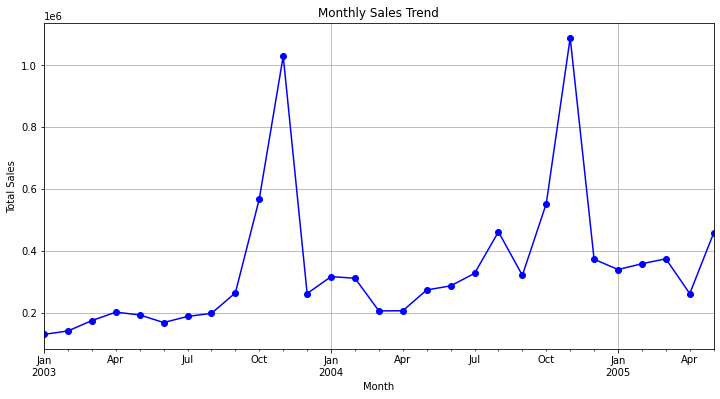

In [6]:
import matplotlib.pyplot as plt

# Convert ORDERDATE to datetime format
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

# Aggregate sales per month
monthly_sales = df.groupby(df["ORDERDATE"].dt.to_period("M"))["SALES"].sum()

# Plot sales trend
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind="line", marker="o", color="blue")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


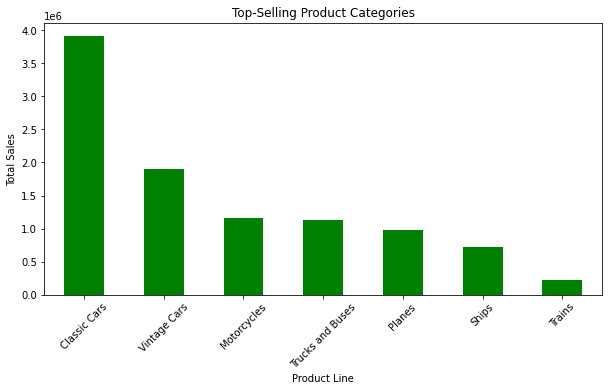

In [7]:
# Aggregate sales per product
top_products = df.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)

# Plot
top_products.plot(kind="bar", color="green", figsize=(10, 5))
plt.title("Top-Selling Product Categories")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


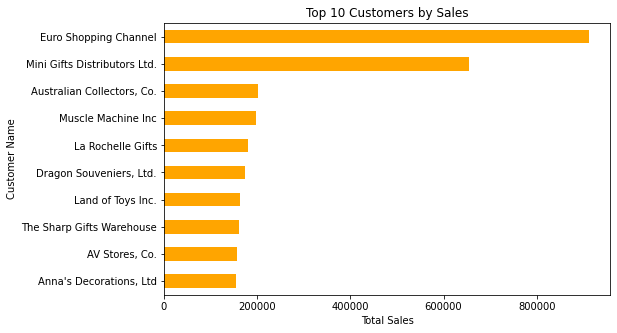

In [8]:
# Find top 10 customers by sales
top_customers = df.groupby("CUSTOMERNAME")["SALES"].sum().sort_values(ascending=False).head(10)

# Plot
top_customers.plot(kind="barh", color="orange", figsize=(8, 5))
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.gca().invert_yaxis()
plt.show()


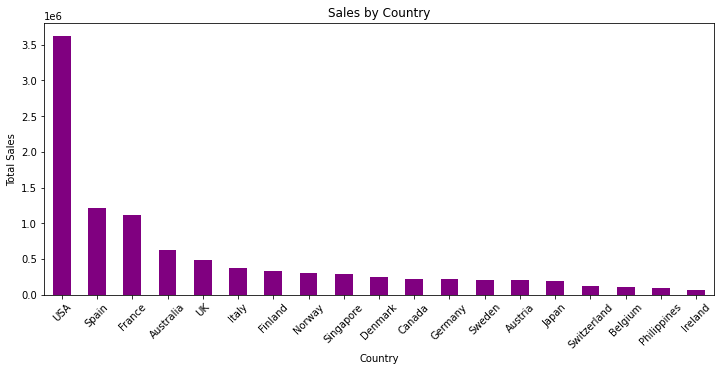

In [9]:
# Aggregate sales per country
sales_by_country = df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False)

# Plot
sales_by_country.plot(kind="bar", figsize=(12, 5), color="purple")
plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


In [10]:
# Convert columns to NumPy arrays
postalcode = np.array(df["POSTALCODE"])  # Extract 'POSTALCODE' column as NumPy array

# Convert non-numeric values to NaN
postalcode_numeric = pd.to_numeric(postalcode, errors="coerce")

# Fill NaN values with median using NumPy
median_postalcode = np.nanmedian(postalcode_numeric)  # Compute median
df["POSTALCODE"] = np.where(np.isnan(postalcode_numeric), median_postalcode, postalcode_numeric)

# Fill missing 'STATE' values with mode using NumPy
state_mode = df["STATE"].mode()[0]
df["STATE"].fillna(state_mode, inplace=True)


In [11]:
# Convert 'SALES' column to NumPy array
sales = np.array(df["SALES"])

# Compute basic statistics
mean_sales = np.mean(sales)
median_sales = np.median(sales)
std_sales = np.std(sales)
max_sales = np.max(sales)
min_sales = np.min(sales)

print(f"Mean Sales: {mean_sales}")
print(f"Median Sales: {median_sales}")
print(f"Standard Deviation: {std_sales}")
print(f"Max Sales: {max_sales}")
print(f"Min Sales: {min_sales}")


Mean Sales: 3553.889071909316
Median Sales: 3184.8
Standard Deviation: 1841.5388520655404
Max Sales: 14082.8
Min Sales: 482.13


In [12]:
# Compute Z-scores
z_scores = (sales - mean_sales) / std_sales

# Identify outliers (values where Z-score > 3 or < -3)
outliers = sales[np.abs(z_scores) > 3]

print("Outliers in Sales:", outliers)


Outliers in Sales: [10993.5  10172.7  11623.7  12001.    9264.86  9774.03 11886.6   9218.16
  9661.44  9245.76  9160.36  9631.   11279.2  10606.2   9470.94  9240.44
 14082.8   9169.   12536.5   9534.5  11887.8  11336.7  10468.9   9720.
 10758.   11739.7   9240.   10039.6  10066.6   9558.8 ]


In [13]:
# Extract product lines and sales data
product_lines = np.array(df["PRODUCTLINE"])
sales = np.array(df["SALES"])

# Find total sales per product line
unique_products, sales_per_product = np.unique(product_lines, return_counts=True)

# Find the best-selling product
best_selling_index = np.argmax(sales_per_product)
best_selling_product = unique_products[best_selling_index]

print(f"Best-Selling Product: {best_selling_product}")


Best-Selling Product: Classic Cars
